# Microservice Anomaly Detection and Root Cause Analysis

For this assignment, we selected a microservice observability dataset instead of a common academic dataset such as Titanic, Iris, or Diabetes.

The chosen problem is relevant to modern cloud-native systems, where multiple services generate metrics, logs, and traces. The objective is to analyze this telemetry data and build an AIOps-style pipeline for detecting anomalies and identifying likely root causes.

## Step 1: Load basic libraries and verify dataset path

In this step, we import the required Python libraries and verify whether the extracted dataset folder is accessible from the notebook.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"D:\BITSP\Sem3\API_CDS\Assignment1")
DATA_DIR = BASE_DIR / "data" / "raw" / "sn_dataset_extracted" / "SN Dataset" / "data"

print("Dataset path exists:", DATA_DIR.exists())
print("Dataset path:", DATA_DIR)

Dataset path exists: True
Dataset path: D:\BITSP\Sem3\API_CDS\Assignment1\data\raw\sn_dataset_extracted\SN Dataset\data


## Step 2: List available experiment folders and fault metadata files

In this step, we check how many observation windows are available in the dataset and identify the corresponding fault metadata files.

In [2]:
run_folders = sorted([p for p in DATA_DIR.iterdir() if p.is_dir()])
fault_files = sorted(DATA_DIR.glob("SN.fault-*.json"))

print("Number of run folders:", len(run_folders))
print("Number of fault files:", len(fault_files))

print("\nRun folders:")
for p in run_folders:
    print("-", p.name)

print("\nFault metadata files:")
for p in fault_files:
    print("-", p.name)

Number of run folders: 4
Number of fault files: 4

Run folders:
- SN.2022-04-17T181245D2022-04-17T183616
- SN.2022-04-17T183729D2022-04-17T190100
- SN.2022-04-17T190213D2022-04-17T192544
- SN.2022-04-17T192658D2022-04-17T195031

Fault metadata files:
- SN.fault-2022-04-17T181245D2022-04-17T183616.json
- SN.fault-2022-04-17T183729D2022-04-17T190100.json
- SN.fault-2022-04-17T190213D2022-04-17T192544.json
- SN.fault-2022-04-17T192658D2022-04-17T195031.json


### Observation

The dataset contains four observation windows, and each window has a matching fault metadata file. This confirms that the telemetry data can be linked with injected fault information for anomaly detection and root cause analysis.

## Step 3: Inspect one fault metadata file

In this step, we read one fault metadata file to understand what type of faults were injected and which microservices were affected.

In [3]:
sample_fault_file = fault_files[0]

with open(sample_fault_file, "r") as f:
    sample_fault_data = json.load(f)

print("Sample fault file:", sample_fault_file.name)
print("Experiment start:", sample_fault_data["start"])
print("Experiment end:", sample_fault_data["end"])
print("Number of injected faults:", len(sample_fault_data["faults"]))

pd.DataFrame(sample_fault_data["faults"])

Sample fault file: SN.fault-2022-04-17T181245D2022-04-17T183616.json
Experiment start: 1650161565.787468
Experiment end: 1650162976.077176
Number of injected faults: 9


,name,fault,start,duration
0,socialnetwork-text-service-1,cpu_load,1.650162e+09,120
1,socialnetwork-text-service-1,network_delay,1.650162e+09,120
2,socialnetwork-text-service-1,network_loss,1.650162e+09,120
3,socialnetwork-home-timeline-service-1,cpu_load,1.650162e+09,120
4,socialnetwork-home-timeline-service-1,network_delay,1.650162e+09,120
5,socialnetwork-home-timeline-service-1,network_loss,1.650162e+09,120
6,socialnetwork-media-service-1,cpu_load,1.650163e+09,120
7,socialnetwork-media-service-1,network_delay,1.650163e+09,120
8,socialnetwork-media-service-1,network_loss,1.650163e+09,120


### Observation

The selected observation window contains nine injected faults across three microservices: text-service, home-timeline-service, and media-service. The fault types are cpu_load, network_delay, and network_loss, each lasting 120 seconds.

## Step 4: Inspect metric files available for one observation window

In this step, we check which microservice metric files are available inside one run folder.

In [4]:
sample_run_folder = run_folders[0]
metrics_dir = sample_run_folder / "metrics"

metric_files = sorted(metrics_dir.glob("*.csv"))

print("Sample run folder:", sample_run_folder.name)
print("Number of metric files:", len(metric_files))

for p in metric_files:
    print("-", p.name)

Sample run folder: SN.2022-04-17T181245D2022-04-17T183616
Number of metric files: 12
- compose-post-service.csv
- home-timeline-service.csv
- media-service.csv
- nginx-web-server.csv
- post-storage-service.csv
- social-graph-service.csv
- text-service.csv
- unique-id-service.csv
- url-shorten-service.csv
- user-mention-service.csv
- user-service.csv
- user-timeline-service.csv


### Observation

The selected observation window contains metric files for 12 microservices. This gives us service-level telemetry data that can be used for DataOps processing, EDA, anomaly labeling, and root cause analysis.

## Step 5: Inspect one microservice metric file

In this step, we inspect the metric structure for one service. Since `text-service` appears in the fault metadata, we use it as the first sample.

In [5]:
sample_metric_file = metrics_dir / "text-service.csv"

metric_df = pd.read_csv(sample_metric_file)

print("Metric file:", sample_metric_file.name)
print("Shape:", metric_df.shape)

display(metric_df.head())
print("Columns:", metric_df.columns.tolist())

Metric file: text-service.csv
Shape: (1411, 8)


,timestamp,cpu_usage_system,cpu_usage_total,cpu_usage_user,memory_usage,memory_working_set,rx_bytes,tx_bytes
0,1650161565,0.63,1.695583,1.05,0.000215,0.000215,1399.0,1747.5
1,1650161566,0.63,1.695583,1.05,0.000215,0.000215,1399.0,1747.5
2,1650161567,0.63,1.695583,1.05,0.000215,0.000215,1399.0,1747.5
3,1650161568,0.63,1.695583,1.05,0.000074,0.000074,1399.0,1747.5
4,1650161569,0.63,1.695583,1.05,0.000074,0.000074,1399.0,1747.5


Columns: ['timestamp', 'cpu_usage_system', 'cpu_usage_total', 'cpu_usage_user', 'memory_usage', 'memory_working_set', 'rx_bytes', 'tx_bytes']


### Observation

The `text-service` metric file contains 1,411 timestamped records and 8 columns. The available metrics include CPU usage, memory usage, receive bytes, and transmit bytes, which are useful for identifying abnormal service behavior during injected faults.

## Step 6: Check missing values and basic statistics

In this step, we check whether the selected metric file has missing values and review basic statistical properties of numeric features.

In [6]:
print("Missing values per column:")
display(metric_df.isnull().sum())

print("Basic statistics:")
display(metric_df.describe())

Missing values per column:


timestamp             0
cpu_usage_system      0
cpu_usage_total       0
cpu_usage_user        0
memory_usage          0
memory_working_set    0
rx_bytes              0
tx_bytes              0
dtype: int64

Basic statistics:


,timestamp,cpu_usage_system,cpu_usage_total,cpu_usage_user,memory_usage,memory_working_set,rx_bytes,tx_bytes
count,1.411000e+03,1411.000000,1411.000000,1411.000000,1411.000000,1411.000000,1411.000000,1411.000000
mean,1.650162e+09,0.263473,0.643116,0.370439,0.000022,0.000021,677.798075,917.456756
std,4.074649e+02,0.894494,2.181963,1.256618,0.000020,0.000020,568.169721,815.572766
min,1.650162e+09,0.000000,0.000000,0.000000,0.000015,0.000015,0.000000,0.000000
25%,1.650162e+09,0.000000,0.000386,0.000000,0.000015,0.000015,250.250000,329.500000
50%,1.650162e+09,0.000000,0.000932,0.000000,0.000015,0.000015,607.000000,726.000000
75%,1.650163e+09,0.000000,0.001826,0.000000,0.000016,0.000016,962.000000,1353.250000
max,1.650163e+09,5.030000,12.282862,7.110000,0.000215,0.000215,3220.000000,5020.000000


### Observation

The selected metric file has no missing values, so no imputation is required for this sample. The CPU and network columns show clear variation, which can help distinguish normal behavior from fault-injected periods.

## Step 7: Convert timestamps and attach fault labels

In this step, we label each metric record as normal or anomalous by comparing its timestamp with the injected fault time windows from the fault metadata file.

In [7]:
fault_df = pd.DataFrame(sample_fault_data["faults"])

# Normalize service name from fault metadata to match metric file naming
fault_df["service_short_name"] = (
    fault_df["name"]
    .str.replace("socialnetwork-", "", regex=False)
    .str.replace("-1", "", regex=False)
)

fault_df["fault_end"] = fault_df["start"] + fault_df["duration"]

display(fault_df)

metric_labeled_df = metric_df.copy()
metric_labeled_df["service"] = "text-service"
metric_labeled_df["event_time"] = pd.to_datetime(metric_labeled_df["timestamp"], unit="s")
metric_labeled_df["is_anomaly"] = 0
metric_labeled_df["fault_type"] = "normal"

for _, fault in fault_df[fault_df["service_short_name"] == "text-service"].iterrows():
    mask = (
        (metric_labeled_df["timestamp"] >= fault["start"]) &
        (metric_labeled_df["timestamp"] <= fault["fault_end"])
    )
    metric_labeled_df.loc[mask, "is_anomaly"] = 1
    metric_labeled_df.loc[mask, "fault_type"] = fault["fault"]

display(metric_labeled_df.head())
display(metric_labeled_df["fault_type"].value_counts())

,name,fault,start,duration,service_short_name,fault_end
0,socialnetwork-text-service-1,cpu_load,1.650162e+09,120,text-service,1.650162e+09
1,socialnetwork-text-service-1,network_delay,1.650162e+09,120,text-service,1.650162e+09
2,socialnetwork-text-service-1,network_loss,1.650162e+09,120,text-service,1.650162e+09
3,socialnetwork-home-timeline-service-1,cpu_load,1.650162e+09,120,home-timeline-service,1.650162e+09
4,socialnetwork-home-timeline-service-1,network_delay,1.650162e+09,120,home-timeline-service,1.650162e+09
5,socialnetwork-home-timeline-service-1,network_loss,1.650162e+09,120,home-timeline-service,1.650162e+09
6,socialnetwork-media-service-1,cpu_load,1.650163e+09,120,media-service,1.650163e+09
7,socialnetwork-media-service-1,network_delay,1.650163e+09,120,media-service,1.650163e+09
8,socialnetwork-media-service-1,network_loss,1.650163e+09,120,media-service,1.650163e+09


,timestamp,cpu_usage_system,cpu_usage_total,cpu_usage_user,memory_usage,memory_working_set,rx_bytes,tx_bytes,service,event_time,is_anomaly,fault_type
0,1650161565,0.63,1.695583,1.05,0.000215,0.000215,1399.0,1747.5,text-service,2022-04-17 02:12:45,0,normal
1,1650161566,0.63,1.695583,1.05,0.000215,0.000215,1399.0,1747.5,text-service,2022-04-17 02:12:46,0,normal
2,1650161567,0.63,1.695583,1.05,0.000215,0.000215,1399.0,1747.5,text-service,2022-04-17 02:12:47,0,normal
3,1650161568,0.63,1.695583,1.05,0.000074,0.000074,1399.0,1747.5,text-service,2022-04-17 02:12:48,0,normal
4,1650161569,0.63,1.695583,1.05,0.000074,0.000074,1399.0,1747.5,text-service,2022-04-17 02:12:49,1,cpu_load


fault_type
normal           1051
cpu_load          120
network_delay     120
network_loss      120
Name: count, dtype: int64

### Observation

The fault metadata was successfully joined with the metric records using timestamp ranges. For `text-service`, 1,051 records are normal and 360 records are anomalous, split equally across `cpu_load`, `network_delay`, and `network_loss`.

## Step 8: Visualize fault distribution for one service

In this step, we visualize the distribution of normal and fault records for `text-service`.

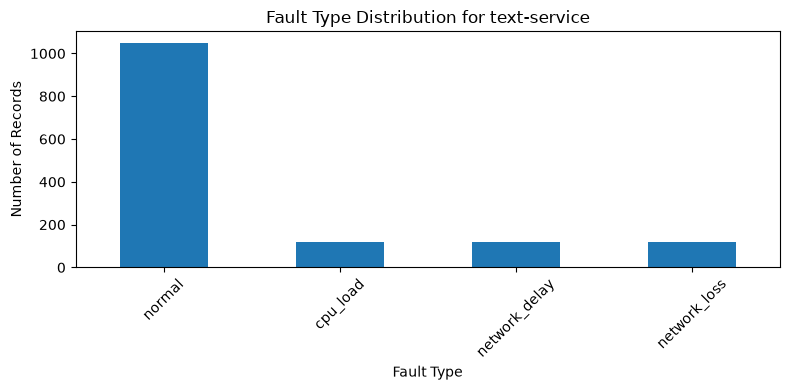

In [8]:
fault_counts = metric_labeled_df["fault_type"].value_counts()

plt.figure(figsize=(8, 4))
fault_counts.plot(kind="bar")
plt.title("Fault Type Distribution for text-service")
plt.xlabel("Fault Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The chart shows that normal records are higher than fault records, but each injected fault type has a balanced count of 120 records. This makes the dataset suitable for both binary anomaly detection and multi-class fault type classification.

## Step 9: Compare CPU usage across normal and fault periods

In this step, we compare CPU usage by fault type to see whether injected faults create measurable changes in service behavior.

<Figure size 800x400 with 0 Axes>

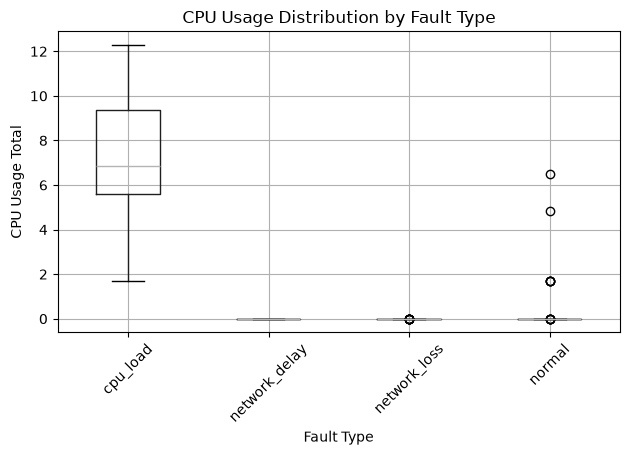

In [9]:
plt.figure(figsize=(8, 4))
metric_labeled_df.boxplot(column="cpu_usage_total", by="fault_type", rot=45)
plt.title("CPU Usage Distribution by Fault Type")
plt.suptitle("")
plt.xlabel("Fault Type")
plt.ylabel("CPU Usage Total")
plt.tight_layout()
plt.show()

### Observation

CPU usage is clearly higher during the `cpu_load` fault period compared with normal, network delay, and network loss periods. This confirms that the metric data captures meaningful behavior changes caused by injected microservice faults.

## Step 10: Compare network traffic across normal and fault periods

In this step, we compare received and transmitted bytes across fault types to understand whether network-related faults affect service communication patterns.

,fault_type,rx_bytes,tx_bytes
0,cpu_load,1078.900000,1548.583333
1,network_delay,621.112500,711.091667
2,network_loss,643.565278,540.169444
3,normal,642.382255,912.036299


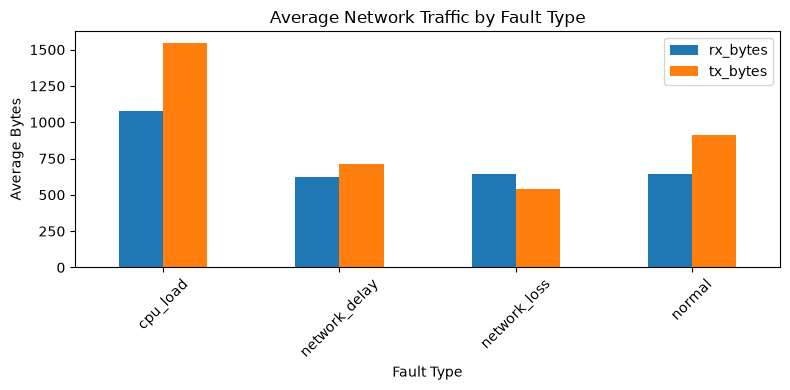

In [10]:
network_summary = (
    metric_labeled_df
    .groupby("fault_type")[["rx_bytes", "tx_bytes"]]
    .mean()
    .reset_index()
)

display(network_summary)

network_summary.set_index("fault_type")[["rx_bytes", "tx_bytes"]].plot(kind="bar", figsize=(8, 4))
plt.title("Average Network Traffic by Fault Type")
plt.xlabel("Fault Type")
plt.ylabel("Average Bytes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Network traffic patterns vary across fault types. The `cpu_load` period shows higher average receive and transmit bytes, while `network_loss` shows lower transmit bytes compared with normal behavior. These differences suggest that network and CPU metrics can support fault-type classification.

## Step 11: Combine metric files from all services in one observation window

In this step, we load all service-level metric CSV files from one observation window and combine them into a single dataframe with a service name column.

In [11]:
service_metric_frames = []

for metric_file in metric_files:
    service_name = metric_file.stem
    temp_df = pd.read_csv(metric_file)
    temp_df["service"] = service_name
    service_metric_frames.append(temp_df)

combined_metrics_df = pd.concat(service_metric_frames, ignore_index=True)

print("Combined metrics shape:", combined_metrics_df.shape)
print("Number of services:", combined_metrics_df["service"].nunique())

display(combined_metrics_df.head())
display(combined_metrics_df["service"].value_counts())

Combined metrics shape: (16932, 9)
Number of services: 12


,timestamp,cpu_usage_system,cpu_usage_total,cpu_usage_user,memory_usage,memory_working_set,rx_bytes,tx_bytes,service
0,1650161565,0.010,0.014129,0.01,0.000013,0.000013,8399.0,11694.0,compose-post-service
1,1650161566,0.010,0.014129,0.01,0.000013,0.000013,8399.0,11694.0,compose-post-service
2,1650161567,0.010,0.014129,0.01,0.000013,0.000013,8399.0,11694.0,compose-post-service
3,1650161568,0.010,0.014129,0.01,0.000013,0.000013,8399.0,11694.0,compose-post-service
4,1650161569,0.005,0.002681,0.00,0.000013,0.000013,1592.0,2712.5,compose-post-service


service
compose-post-service     1411
home-timeline-service    1411
media-service            1411
nginx-web-server         1411
post-storage-service     1411
social-graph-service     1411
text-service             1411
unique-id-service        1411
url-shorten-service      1411
user-mention-service     1411
user-service             1411
user-timeline-service    1411
Name: count, dtype: int64

### Observation

All 12 microservice metric files were successfully combined into one dataframe. Each service has 1,411 timestamped records, giving a total of 16,932 records for one observation window.

## Step 12: Apply anomaly labels to all services in one observation window

In this step, we use the fault metadata to label every service record as normal or anomalous. Records falling inside a known fault window are marked as anomalous and assigned the corresponding fault type.

In [12]:
labeled_all_services_df = combined_metrics_df.copy()
labeled_all_services_df["event_time"] = pd.to_datetime(labeled_all_services_df["timestamp"], unit="s")
labeled_all_services_df["is_anomaly"] = 0
labeled_all_services_df["fault_type"] = "normal"
labeled_all_services_df["root_cause_service"] = "none"

for _, fault in fault_df.iterrows():
    service_name = fault["service_short_name"]
    mask = (
        (labeled_all_services_df["service"] == service_name) &
        (labeled_all_services_df["timestamp"] >= fault["start"]) &
        (labeled_all_services_df["timestamp"] <= fault["fault_end"])
    )
    labeled_all_services_df.loc[mask, "is_anomaly"] = 1
    labeled_all_services_df.loc[mask, "fault_type"] = fault["fault"]
    labeled_all_services_df.loc[mask, "root_cause_service"] = service_name

print("Labeled dataframe shape:", labeled_all_services_df.shape)

print("\nAnomaly distribution:")
display(labeled_all_services_df["is_anomaly"].value_counts())

print("\nFault type distribution:")
display(labeled_all_services_df["fault_type"].value_counts())

print("\nRoot cause service distribution:")
display(labeled_all_services_df["root_cause_service"].value_counts())

Labeled dataframe shape: (16932, 13)

Anomaly distribution:


is_anomaly
0    15852
1     1080
Name: count, dtype: int64


Fault type distribution:


fault_type
normal           15852
cpu_load           360
network_delay      360
network_loss       360
Name: count, dtype: int64


Root cause service distribution:


root_cause_service
none                     15852
home-timeline-service      360
media-service              360
text-service               360
Name: count, dtype: int64

### Observation

After applying fault labels, the combined dataset contains 16,932 records for one observation window. Most records are normal, while 1,080 records are anomalous across three fault types and three root-cause services.

## Step 13: Visualize anomaly and root-cause distribution

In this step, we visualize how many records are normal/anomalous and which services are involved as root causes.

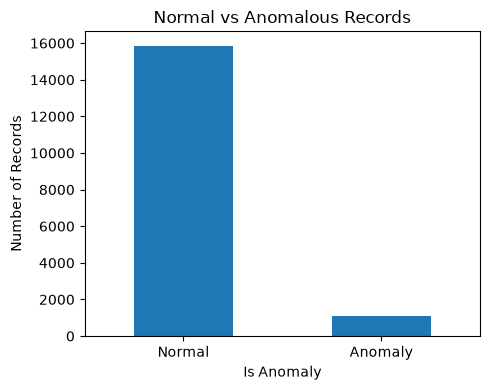

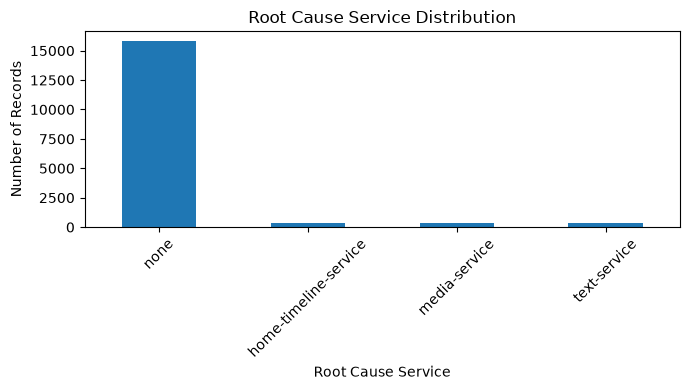

In [13]:
plt.figure(figsize=(5, 4))
labeled_all_services_df["is_anomaly"].value_counts().sort_index().plot(kind="bar")
plt.title("Normal vs Anomalous Records")
plt.xlabel("Is Anomaly")
plt.ylabel("Number of Records")
plt.xticks(ticks=[0, 1], labels=["Normal", "Anomaly"], rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
labeled_all_services_df["root_cause_service"].value_counts().plot(kind="bar")
plt.title("Root Cause Service Distribution")
plt.xlabel("Root Cause Service")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The dataset is imbalanced because normal records are much higher than anomalous records. The anomalous records are linked to three root-cause services: home-timeline-service, media-service, and text-service.

## Step 14: Build a reusable function for labeling one observation window

In this step, we convert the earlier logic into a reusable function so that all observation windows can be processed consistently.

In [14]:
def load_and_label_run(run_folder, fault_file):
    with open(fault_file, "r") as f:
        fault_data = json.load(f)

    fault_df = pd.DataFrame(fault_data["faults"])
    fault_df["service_short_name"] = (
        fault_df["name"]
        .str.replace("socialnetwork-", "", regex=False)
        .str.replace("-1", "", regex=False)
    )
    fault_df["fault_end"] = fault_df["start"] + fault_df["duration"]

    metrics_dir = run_folder / "metrics"
    metric_files = sorted(metrics_dir.glob("*.csv"))

    frames = []
    for metric_file in metric_files:
        service_name = metric_file.stem
        temp_df = pd.read_csv(metric_file)
        temp_df["service"] = service_name
        temp_df["run_id"] = run_folder.name
        frames.append(temp_df)

    df = pd.concat(frames, ignore_index=True)
    df["event_time"] = pd.to_datetime(df["timestamp"], unit="s")
    df["is_anomaly"] = 0
    df["fault_type"] = "normal"
    df["root_cause_service"] = "none"

    for _, fault in fault_df.iterrows():
        service_name = fault["service_short_name"]
        mask = (
            (df["service"] == service_name) &
            (df["timestamp"] >= fault["start"]) &
            (df["timestamp"] <= fault["fault_end"])
        )
        df.loc[mask, "is_anomaly"] = 1
        df.loc[mask, "fault_type"] = fault["fault"]
        df.loc[mask, "root_cause_service"] = service_name

    return df


test_df = load_and_label_run(run_folders[0], fault_files[0])

print("Test labeled shape:", test_df.shape)
display(test_df.head())
display(test_df["fault_type"].value_counts())

Test labeled shape: (16932, 14)


,timestamp,cpu_usage_system,cpu_usage_total,cpu_usage_user,memory_usage,memory_working_set,rx_bytes,tx_bytes,service,run_id,event_time,is_anomaly,fault_type,root_cause_service
0,1650161565,0.010,0.014129,0.01,0.000013,0.000013,8399.0,11694.0,compose-post-service,SN.2022-04-17T181245D2022-04-17T183616,2022-04-17 02:12:45,0,normal,none
1,1650161566,0.010,0.014129,0.01,0.000013,0.000013,8399.0,11694.0,compose-post-service,SN.2022-04-17T181245D2022-04-17T183616,2022-04-17 02:12:46,0,normal,none
2,1650161567,0.010,0.014129,0.01,0.000013,0.000013,8399.0,11694.0,compose-post-service,SN.2022-04-17T181245D2022-04-17T183616,2022-04-17 02:12:47,0,normal,none
3,1650161568,0.010,0.014129,0.01,0.000013,0.000013,8399.0,11694.0,compose-post-service,SN.2022-04-17T181245D2022-04-17T183616,2022-04-17 02:12:48,0,normal,none
4,1650161569,0.005,0.002681,0.00,0.000013,0.000013,1592.0,2712.5,compose-post-service,SN.2022-04-17T181245D2022-04-17T183616,2022-04-17 02:12:49,0,normal,none


fault_type
normal           15852
cpu_load           360
network_delay      360
network_loss       360
Name: count, dtype: int64

### Observation

The reusable function successfully reproduces the same labeling output for one observation window. This function can now be used to process all available runs in a consistent DataOps-style ingestion and labeling workflow.

## Step 15: Process all observation windows

In this step, we apply the reusable labeling function to all run folders and combine the result into one final dataset for EDA and machine learning.

In [15]:
all_run_frames = []

for run_folder, fault_file in zip(run_folders, fault_files):
    print("Processing:", run_folder.name)
    run_df = load_and_label_run(run_folder, fault_file)
    all_run_frames.append(run_df)

final_df = pd.concat(all_run_frames, ignore_index=True)

print("Final combined dataset shape:", final_df.shape)
print("Number of runs:", final_df["run_id"].nunique())
print("Number of services:", final_df["service"].nunique())

print("\nAnomaly distribution:")
display(final_df["is_anomaly"].value_counts())

print("\nFault type distribution:")
display(final_df["fault_type"].value_counts())

print("\nRoot cause service distribution:")
display(final_df["root_cause_service"].value_counts())

Processing: SN.2022-04-17T181245D2022-04-17T183616
Processing: SN.2022-04-17T183729D2022-04-17T190100
Processing: SN.2022-04-17T190213D2022-04-17T192544
Processing: SN.2022-04-17T192658D2022-04-17T195031
Final combined dataset shape: (67752, 14)
Number of runs: 4
Number of services: 12

Anomaly distribution:


is_anomaly
0    63792
1     3960
Name: count, dtype: int64


Fault type distribution:


fault_type
normal           63792
cpu_load          1320
network_delay     1320
network_loss      1320
Name: count, dtype: int64


Root cause service distribution:


root_cause_service
none                     63792
home-timeline-service      360
media-service              360
text-service               360
post-storage-service       360
social-graph-service       360
url-shorten-service        360
unique-id-service          360
user-service               360
compose-post-service       360
user-mention-service       360
user-timeline-service      360
Name: count, dtype: int64

### Observation

All four observation windows were processed and combined into one final dataset with 67,752 records across 12 microservices. The dataset contains 3,960 anomalous records, equally distributed across three fault types: cpu_load, network_delay, and network_loss.

## Step 16: Save the processed labeled dataset

In this step, we save the final labeled dataset as a CSV file. This processed file will be used by the final automated Prefect pipeline for EDA, model training, and evaluation.

In [16]:
processed_dir = BASE_DIR / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

processed_file = processed_dir / "microservice_rca_labeled_metrics.csv"

final_df.to_csv(processed_file, index=False)

print("Processed dataset saved to:", processed_file)
print("File exists:", processed_file.exists())
print("Final shape:", final_df.shape)

Processed dataset saved to: D:\BITSP\Sem3\API_CDS\Assignment1\data\processed\microservice_rca_labeled_metrics.csv
File exists: True
Final shape: (67752, 14)


### Observation

The final labeled dataset was successfully saved as a processed CSV file. This file will act as the clean input dataset for the automated DataOps and MLOps pipeline.

## Step 17: Final dataset summary

In this step, we summarize the final dataset after combining all observation windows and applying anomaly/root-cause labels.

In [18]:
summary = {
    "Total records": final_df.shape[0],
    "Total columns": final_df.shape[1],
    "Observation windows": final_df["run_id"].nunique(),
    "Microservices": final_df["service"].nunique(),
    "Normal records": int((final_df["is_anomaly"] == 0).sum()),
    "Anomalous records": int((final_df["is_anomaly"] == 1).sum()),
    "Fault types": ", ".join(sorted(final_df["fault_type"].unique())),
    "Root cause services": final_df[final_df["root_cause_service"] != "none"]["root_cause_service"].nunique()
}

summary_df = pd.DataFrame(summary.items(), columns=["Item", "Value"])
display(summary_df)

,Item,Value
0,Total records,67752
1,Total columns,14
2,Observation windows,4
3,Microservices,12
4,Normal records,63792
5,Anomalous records,3960
6,Fault types,"cpu_load, network_delay, network_loss, normal"
7,Root cause services,11


### Observation

The final processed dataset contains 67,752 records from four observation windows and 12 microservices. It has enough labeled data for two ML tasks: binary anomaly detection and multi-class fault type classification.

## Step 18: Save important EDA charts

In this step, we save key charts as image files so they can be reused in the final report.

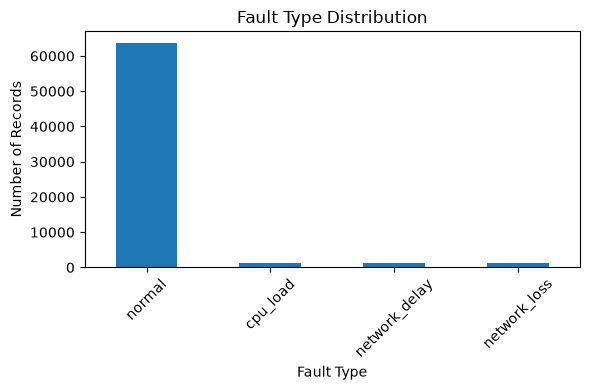

Chart saved to: D:\BITSP\Sem3\API_CDS\Assignment1\outputs\charts\fault_type_distribution.png


In [19]:
charts_dir = BASE_DIR / "outputs" / "charts"
charts_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6, 4))
final_df["fault_type"].value_counts().plot(kind="bar")
plt.title("Fault Type Distribution")
plt.xlabel("Fault Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()

chart_path = charts_dir / "fault_type_distribution.png"
plt.savefig(chart_path, dpi=150)
plt.show()

print("Chart saved to:", chart_path)